<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Neural networks with SKlearn**


In this lab, we will be implementing neural networks for a real-world task (ditgit recognition) using the **Multi-layer Perceptron (MLP)** classifier from scikit-learn.



## **Table of Contents**

1. [Objectives](#toc-objectives)
2. [Setup](#toc-setup)
    1. [Installing Required Libraries](#toc-installing-required-libraries)
    2. [Importing Required Libraries](#toc-importing-required-libraries)
3. [Background](#toc-background)
4. [Example: Digit Recognition with Multi-layer Perceptron](#toc-example-digit-recognition-with-multi-layer-perceptron)



## **Objectives** <a id="toc-objectives"></a>

After completing this lab you will be able to:

*   Apply MLP for classification tasks
*   Use RandomizedSearchCV to search for an optimal set of model parameters  


## **Setup** <a id="toc-setup"></a>


For this lab, we will be using the following libraries:

*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`Pillow`](https://pillow.readthedocs.io/en/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for image processing functions.
*   [`OpenCV`](https://docs.opencv.org/4.x/index.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for other image processing functions.
*   [`tensorflow`](https://www.tensorflow.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and neural network related functions.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


### **Installing Required Libraries** <a id="toc-installing-required-libraries"></a>

The following required libraries are pre-installed in the Skills Network Labs environment. However, if you run this notebook command in a different Jupyter environment (like Watson Studio or Anaconda), you will need to install these libraries by removing the `#` sign before `!mamba` in the following code cell.


In [1]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy numpy==1.22.3 matplotlib==3.5.1 tensorflow==2.9.0 opencv-python==4.5.5.62

# Note: If your environment doesn't support "!mamba install", use "!pip install --user"

# RESTART YOUR KERNEL AFTERWARD AS WELL

### **Importing Required Libraries** <a id="toc-importing-required-libraries"></a>

*We recommend you import all required libraries in one place (here):*


In [2]:
import warnings

warnings.simplefilter("ignore")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

## **Background** <a id="toc-background"></a>



The `scikit-learn` library provides many powerful tools for machine learning, including regression, classification, clustering, and neural network models. One of its neural network interfaces is the **Multi-layer Perceptron (MLP)** class.

A **Multi-layer Perceptron (MLP)** is a type of artificial neural network (ANN). It is called a *feedforward* network because information moves in one direction, from the input layer to the output layer. An MLP usually contains three types of layers:

1. **Input layer** – receives the input features  
2. **Hidden layer(s)** – learns patterns and relationships in the data  
3. **Output layer** – produces the final prediction  

Each neuron in the hidden and output layers applies a nonlinear **activation function**, such as ReLU. These nonlinear functions allow the model to learn complex patterns that cannot be solved using simple linear models.

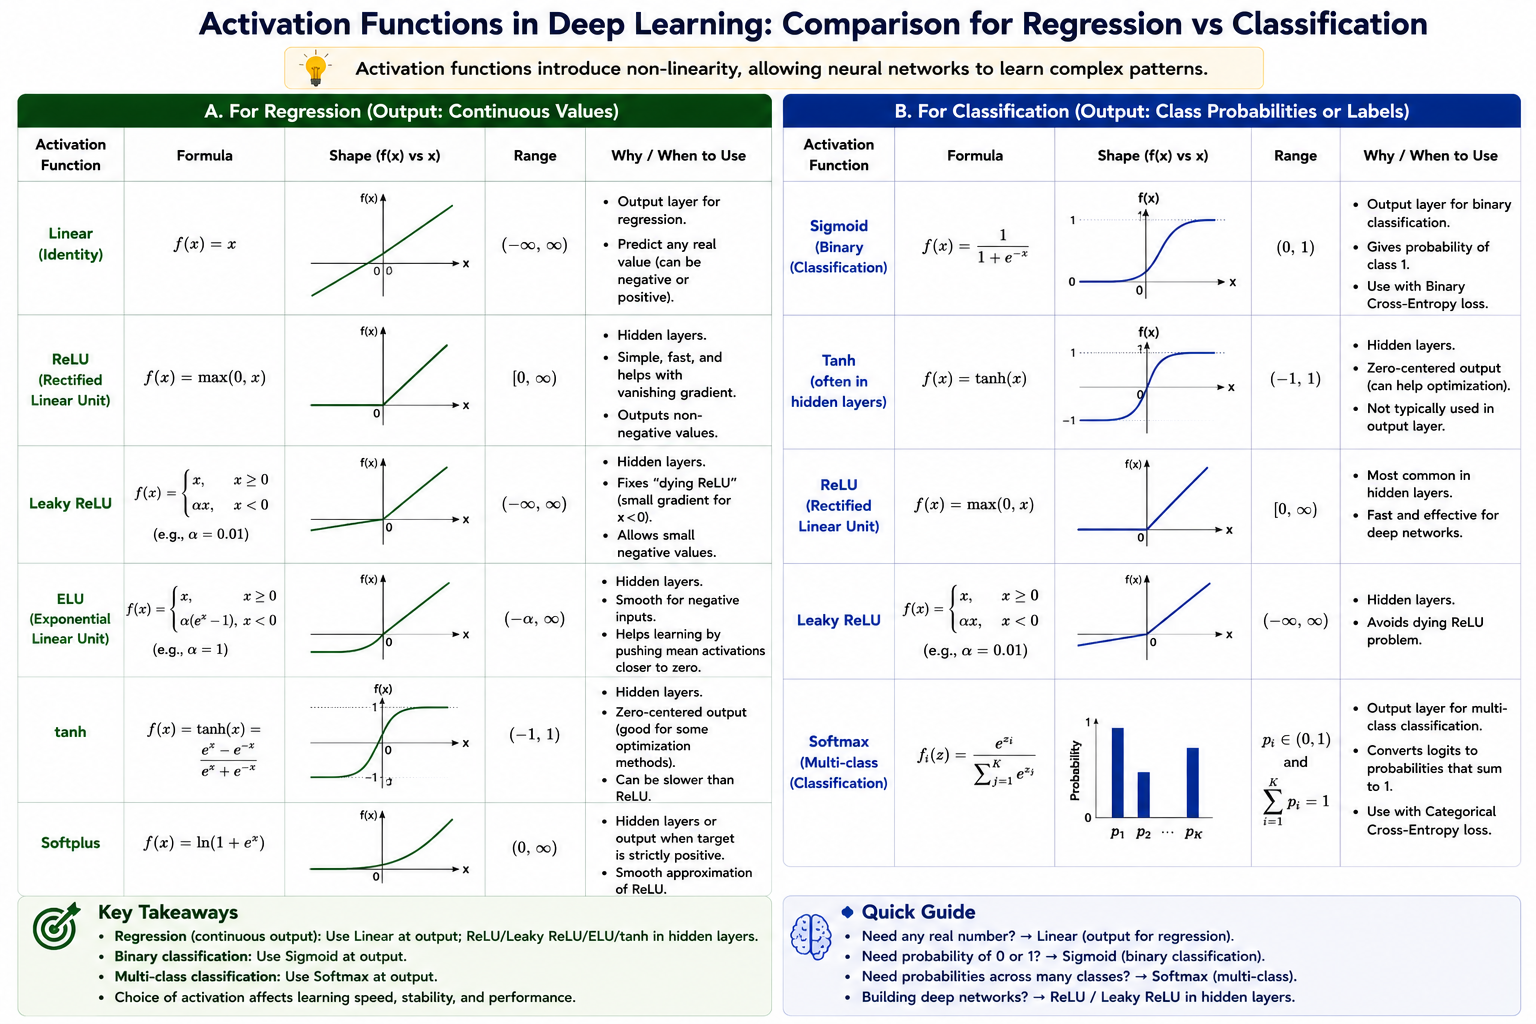

The `MLPClassifier` class in `scikit-learn` is designed for classification tasks. It is trained using a supervised learning method called **backpropagation**, which updates the network weights to reduce prediction error during training.

Because MLP models contain multiple layers and nonlinear activation functions, they can learn data that is **not linearly separable**, making them more flexible than traditional linear models.

Multilayer perceptrons are sometimes called **"vanilla" neural networks**, especially when they contain only a single hidden layer.

<center>
<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L1/Artificial_neural_network.svg" width="50%">
</center>

<center><b>Illustration of a One-Hidden-Layer MLP</b></center>

## **Example: Digit Recognition with Multi-layer Perceptron** <a id="toc-example-digit-recognition-with-multi-layer-perceptron"></a>

In this example, you will implement a simple neural network using scikit-learn's **MLPClassifier** function. The goal is to correctly identify digits from a dataset of tens of thousands of handwritten images from [kaggle](https://www.kaggle.com/code/cezaryszulc/sklearn-simple-neural-network/notebook?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01).

Let's download the digits dataset and display a few images!


In [3]:
digits = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L1/data/digits.csv"
)

labels = digits["label"]
digits = np.array(digits.drop("label", axis=1)).astype("float")
digits.shape, labels.shape

((42000, 784), (42000,))

There are 42,000 digit images and each has 784 pixels, which means we can reshape them into $28\times28$ images for displaying.


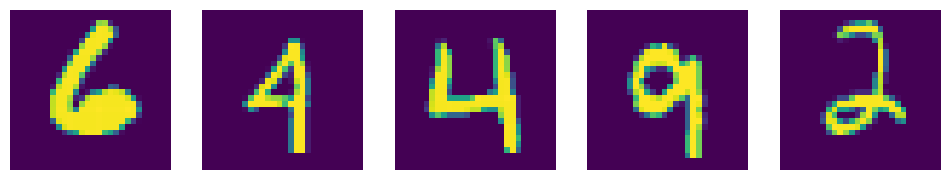

In [4]:
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(random.choice(digits).reshape(28, 28))
    plt.axis("off")

Let's split the 42,000 images into train and test sets.


In [5]:
# Define the training split ratio (70% train, 30% test)
train_ratio = 0.7

# Normalize data to a 0.0 - 1.0 range
digits /= 255.0

# Calculate the single boundary index
split_ind = int(len(digits) * train_ratio)

# Slice the data into train and test sets
X_train, X_test = digits[:split_ind], digits[split_ind:]
y_train, y_test = labels[:split_ind], labels[split_ind:]

# Verify the resulting dimensions
X_train.shape, X_test.shape

((29399, 784), (12601, 784))

### **Hyperparameter Optimization for `MLPClassifier`**

Using `scikit-learn`'s **`GridSearchCV`**, you can systematically evaluate combinations of the following core hyperparameters to optimize the neural network's performance and generalization:

 `hidden_layer_sizes`
* **Type & Default:** `tuple`, default=`(100,)`
* **Description:** Defines the network's structural topology. The length of the tuple determines the number of hidden layers, and the $i$-th element specifies the number of neurons within the $i$-th hidden layer.
* **Example:** `(100, 50)` creates a two-layer architecture with 100 neurons in the first hidden layer and 50 in the second.

 `alpha`
* **Type & Default:** `float`, default=`0.0001`
* **Description:** Determines the intensity of the **L2 regularization** (weight decay) penalty term. This penalty prevents overfitting by discouraging excessively large weight magnitudes. 
* **Note:** To ensure the regularization effect remains consistent regardless of your batch or dataset volume, the L2 penalty is automatically divided by the sample size before being added to the loss function.

 `max_iter`
* **Type & Default:** `int`, default=`200`
* **Description:** Sets the hard upper bound on training iterations. The chosen solver will optimize continuously until the model achieves convergence (controlled by the `tol` parameter) or reaches this maximum value.
* **Stochastic Solvers (`'sgd'`, `'adam'`):** For these algorithms, `max_iter` explicitly defines the maximum number of **epochs** (complete passes through the entire training dataset), rather than individual gradient update steps.

 `learning_rate_init`
* **Type & Default:** `float`, default=`0.001`
* **Description:** Sets the initial step size for weight updates during optimization. This parameter is exclusively utilized when the `solver` is set to `'sgd'` or `'adam'`.
* **Impact:** A higher initial learning rate can speed up convergence but risks instability, while a lower rate provides steady convergence at the expense of computational time.

Before we search for an optimal set of parameters, let's start with a vanilla MLPClassifier:


In [6]:
model = MLPClassifier().fit(X_train, y_train)
y_pred = model.predict(X_test)

print(
    f"Using MLPClassifier with the default parameter values gives an accuracy of {accuracy_score(y_pred, y_test)}"
)

Using MLPClassifier with the default parameter values gives an accuracy of 0.9720657090707087


In [7]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1273
           1       0.99      0.98      0.98      1425
           2       0.96      0.98      0.97      1209
           3       0.97      0.97      0.97      1313
           4       0.97      0.98      0.98      1179
           5       0.96      0.97      0.96      1126
           6       0.98      0.98      0.98      1232
           7       0.98      0.98      0.98      1333
           8       0.97      0.96      0.97      1246
           9       0.95      0.96      0.96      1265

    accuracy                           0.97     12601
   macro avg       0.97      0.97      0.97     12601
weighted avg       0.97      0.97      0.97     12601



### **Hyperparameter Search Strategy**

For this cross-validation training, we will use the default Rectified Linear Unit (`"relu"`) activation function and the default `"adam"` optimizer. 

To optimize our remaining hyperparameters, we will use **`RandomizedSearchCV`** instead of **`GridSearchCV`**. `RandomizedSearchCV` significantly reduces total training time because it does not evaluate every possible parameter combination. Instead, it randomly samples a fixed number of parameter settings from specified distributions.

The figure below illustrates the structural difference between these two search techniques:

<center><img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L1/data/randomsearch.png" width="65%"></center>

<p style="text-align:center">
<a href="https://dl.acm.org/doi/pdf/10.5555/2188385.2188395?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01"> Source: Random Search for Hyper-Parameter Optimization paper</a>
</p>


**Why Randomized Search is More Efficient**

In any machine learning model, some hyperparameters drastically impact performance (important parameters), while others have a minimal effect (unimportant parameters). 

* **The Problem with Grid Search:** Because `GridSearchCV` places points on a rigid, evenly spaced grid, it repeatedly tests the exact same values for individual parameters across different combinations. If a parameter turns out to be unimportant, testing multiple variations of it wastes significant computational time without discovering better models.
* **The Advantage of Random Search:** By sampling points unevenly, `RandomizedSearchCV` ensures that almost every single trial evaluates a completely unique value for *every* parameter. This allows the search to explore a far greater variety of distinct values within the important parameter space using the exact same number of trials.

Because we cannot know which hyperparameter subspaces are the most critical before training, relying on a strict grid is highly inefficient. Random sampling provides much better coverage of the parameter space for a fraction of the computational cost.

However, despite the fact that we will use a more efficient search method since we are trying out multiple values for mutiple parameters of a neural network , **you should still expect training time to be much longer than training a single model**.


In [8]:
parameters = {
    "hidden_layer_sizes": [50, 100, 200],
    "alpha": [0.001, 0.01, 0.1],
    "max_iter": [200, 500, 800],
    "learning_rate_init": [0.0001, 0.001, 0.01, 0.1],
}

model = MLPClassifier()
clf = RandomizedSearchCV(estimator=model, param_distributions=parameters, cv=5)
clf.fit(
    X_train[:3000], y_train[:3000]
)  # reduce the train set size to shorten the training time

print("The best parameter values found are:\n")
print(clf.best_params_)

# store the best model found in "bestmodel"
bestmodel = clf.best_estimator_

The best parameter values found are:

{'max_iter': 500, 'learning_rate_init': 0.001, 'hidden_layer_sizes': 200, 'alpha': 0.1}


Now we can use the **bestmodel**, which uses the most optimal set of parameter values found by RandomSearchCV, cross-validated on a subset of the training set, to make predictions for the test set **X_test** and evaluate its performance.

You select the best regularization  method using the validation data.


The accuracy score of the best model is 0.9402428378700103



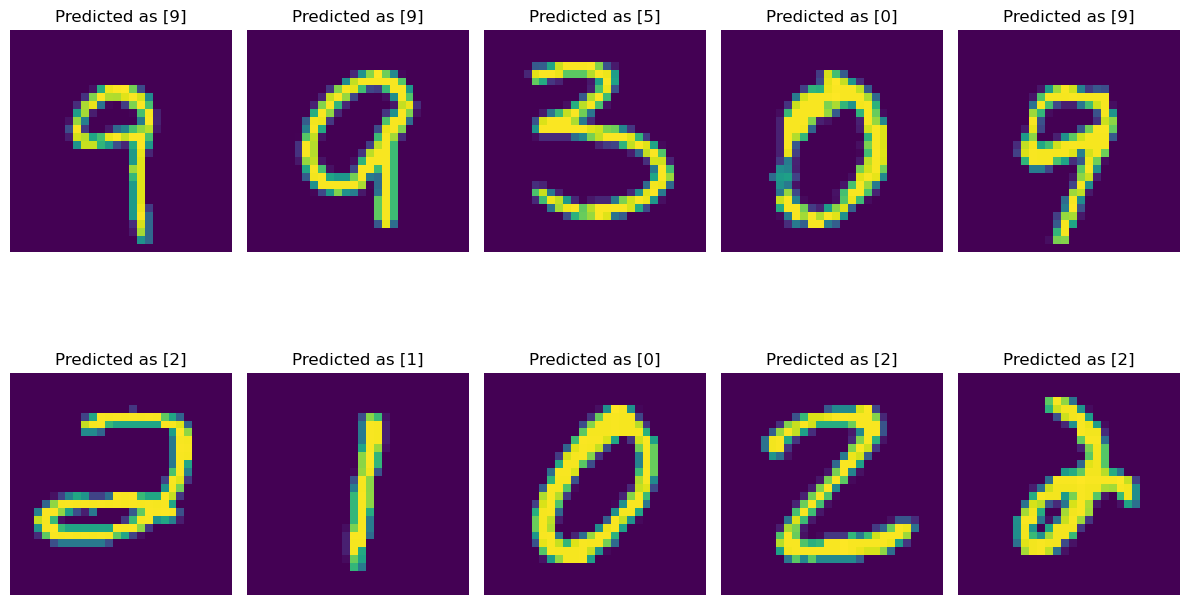

In [9]:
y_pred = bestmodel.predict(X_test)
print(
    f"The accuracy score of the best model is {accuracy_score(y_test, y_pred)}\n"
)

plt.figure(figsize=(12, 8))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    sample = random.choice(X_test)
    plt.imshow(sample.reshape(28, 28))
    pred = bestmodel.predict(sample.reshape(1, -1))
    plt.title(f"Predicted as {pred}")
    plt.axis("off")

plt.tight_layout()

The accuracy of our model is around 93% and the 10 random samples from the test set are all predicted correctly, which is pretty nice. 


## **Authors**


[Roxanne Li](https://www.linkedin.com/in/roxanne-li/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01) is a Data Science intern at IBM Skills Network, entering level-5 study in the Mathematics & Statistics undergraduate Coop program at McMaster University.

Su Wu


## **Change Log**


| Date (YYYY-MM-DD) | Version | Changed By  | Change Description |
| ----------------- | ------- | ----------- | ------------------ |
| 2022-07-07        | 0.1     | Roxanne Li  | Created Lab       |
| 2022-09-06        | 0.1     | Steve Hord  | QA pass edits     |
| 2026-05-18        | 0.1     | Su Wu       | Documentation and code edits|

Copyright © 2022 IBM Corporation. All rights reserved.
